In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image, ImageOps
import csv
import random
import gradio as gr
import pandas as pd
import numpy as np
import random
import csv
import os
from PIL import Image, ImageOps

In [ ]:
# Задаем пути
features_csv = "../data/interim/building_features_402-32d-b2.csv"
images_dir = "../../data/processed/inference-402-imgs-v2"
output_dir = "../data/input/ranking-dataset/"
classes = ["coating_deterioration",
           "masonry_degradation",
           "moisture_bio_damage", 
           "vandalism"
           ]
features = ['mean', 
            'max', 
            'prevalence', 
            'std', 
            'q75', 
            'skewness',          
            'concentration', 
            'severity_coverage'
            ]
target_pairs = 150 # просто для ориентира (может быть любым числом)
adapt_window = 400 # по факту не используется
epsilon = 0.01 # чтобы не делить на 0

# Пороги по показателю `max` для отобора пар для разметки
annotation_threshold = {
    "coating_deterioration": 0.03,
    "masonry_degradation": 0.03,
    "moisture_bio_damage": 0.03,
    "vandalism": 0.015,
}

In [9]:
# Загрузка данных
df = pd.read_csv(features_csv)

# Выбираем только числовые фичи (отбрасываем building_name и num_tiles)
feature_cols = [col for col in df.columns if col not in ['building_name', 'num_tiles']]

# Вывод основных статистик по всем признакам
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
coating_deterioration_mean,402.0,0.071265,0.091506,0.000081,0.012811,0.033722,0.090877,0.500476
coating_deterioration_max,402.0,0.180423,0.172921,0.000205,0.048336,0.129805,0.256005,0.841841
coating_deterioration_prevalence,402.0,0.586439,0.328714,0.000000,0.333333,0.625000,0.875000,1.000000
coating_deterioration_std,402.0,0.051814,0.049923,0.000088,0.014723,0.037998,0.070525,0.265403
coating_deterioration_q75,402.0,0.097995,0.125351,0.000000,0.012852,0.043732,0.133653,0.625235
coating_deterioration_skewness,402.0,1.109316,0.911980,-0.972760,0.501774,1.012883,1.696664,4.192816
coating_deterioration_concentration,402.0,0.314110,0.181727,0.000000,0.195439,0.292201,0.425468,0.937248
coating_deterioration_severity_coverage,402.0,0.144980,0.171024,0.000000,0.017769,0.074282,0.208993,0.806764
masonry_degradation_mean,402.0,0.002886,0.005805,0.000000,0.000192,0.000795,0.002673,0.049613
masonry_degradation_max,402.0,0.018308,0.031815,0.000000,0.001116,0.005090,0.018392,0.253272


## Анализ сырых результатов инференса

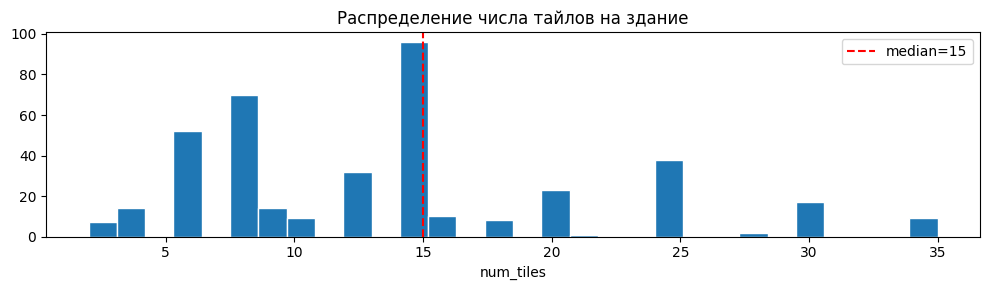


Здания с < 4 тайлами:
     building_name  num_tiles
43             289          2
67             271          2
125            254          3
246            233          2
257            157          2
301            312          3
344            266          2


In [10]:
#  Распределение num_tiles
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(df["num_tiles"], bins=30, edgecolor="white")
ax.axvline(df["num_tiles"].median(), color="red", linestyle="--",
           label=f"median={df['num_tiles'].median():.0f}")
ax.set_title("Распределение числа тайлов на здание")
ax.set_xlabel("num_tiles")
ax.legend()
plt.tight_layout()
plt.savefig("plot_num_tiles.png", dpi=130)
plt.show()

# Здания с подозрительно малым числом тайлов
print("\nЗдания с < 4 тайлами:")
print(df[df["num_tiles"] < 4][["building_name", "num_tiles"]])


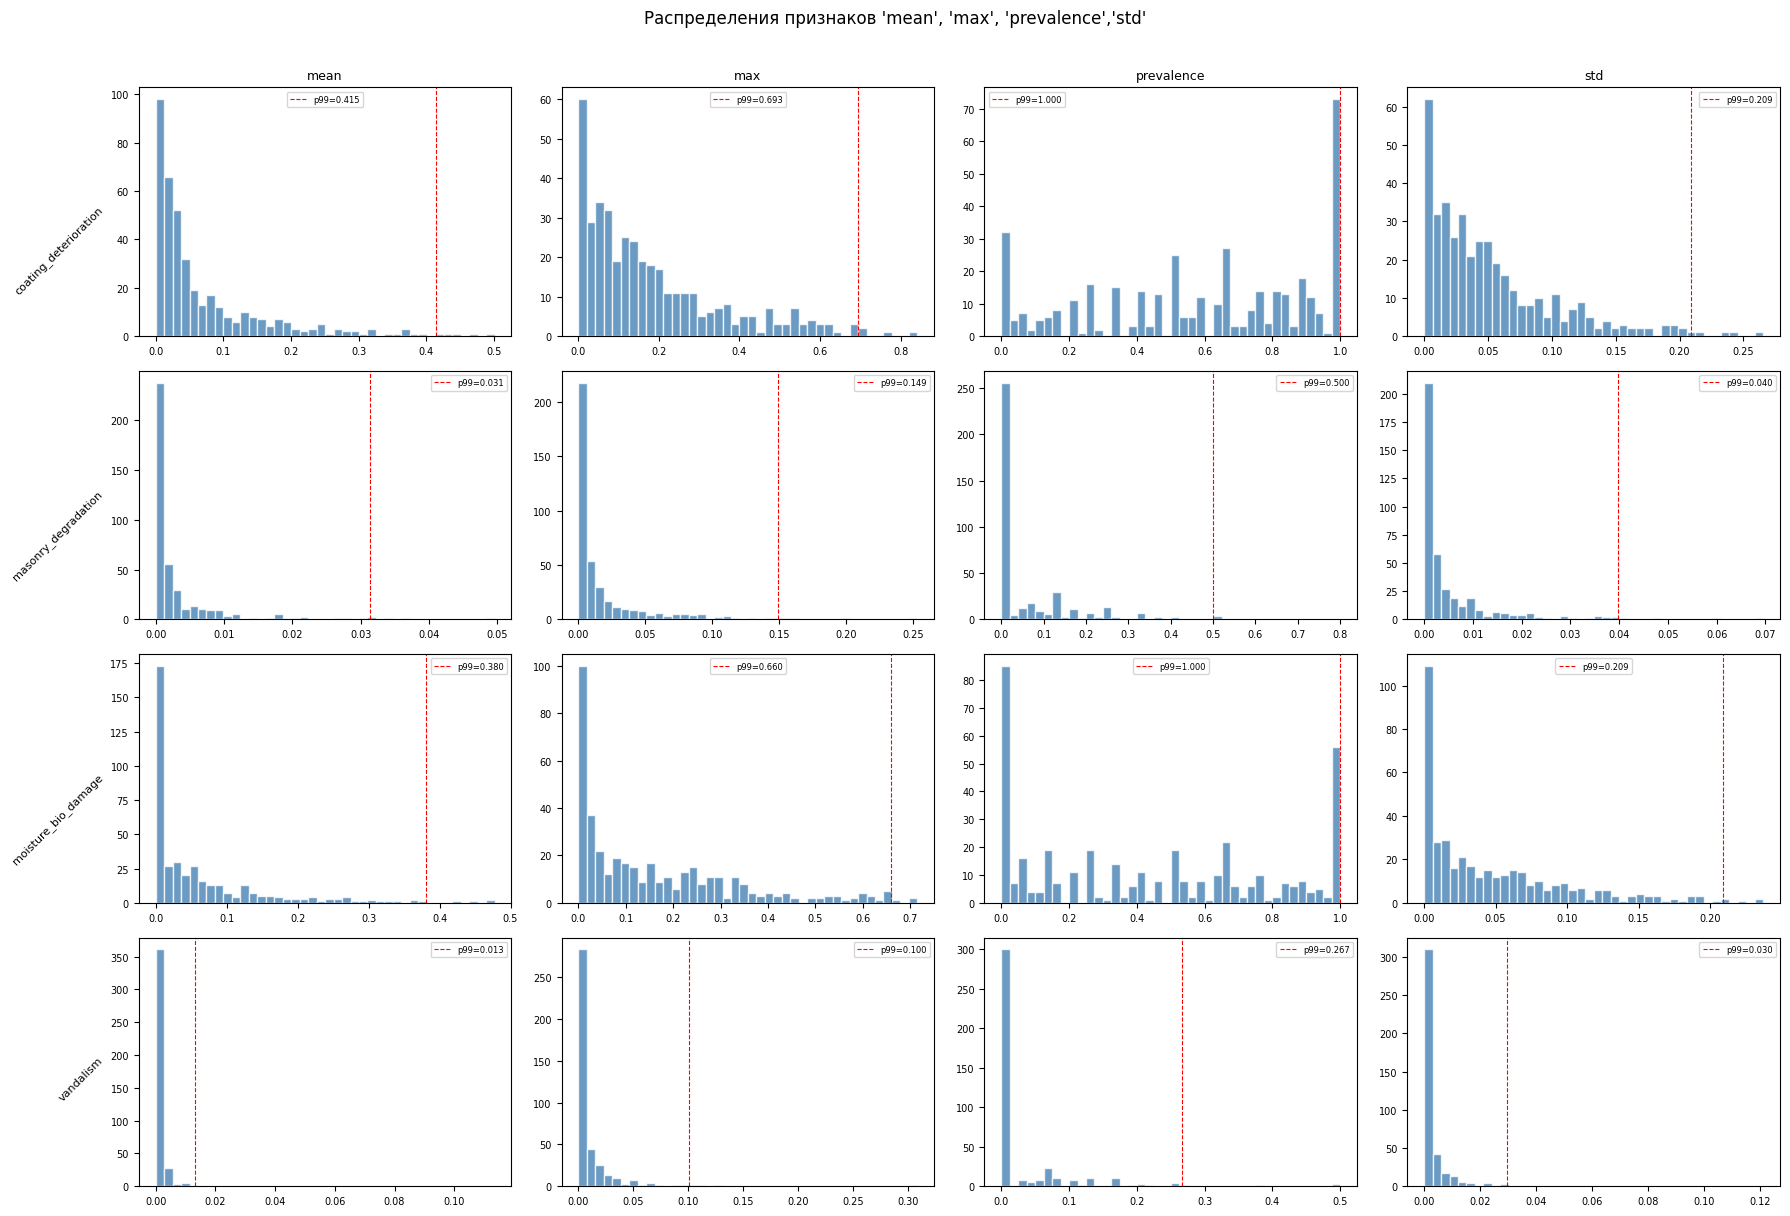

In [ ]:
# Распределения признаков по каждому классу 
fig, axes = plt.subplots(len(classes), len(features) // 2,
                          figsize=(18, len(classes) * 3))

for i, cls in enumerate(classes):
    for j, feat in enumerate(features[:4]):
        col = f"{cls}_{feat}"
        vals = df[col].dropna()
        ax = axes[i, j]

        ax.hist(vals, bins=40, edgecolor="white", color="steelblue", alpha=0.8)
        p99 = np.percentile(vals, 99)
        ax.axvline(p99, color="red", linestyle="--", linewidth=0.8,
                   label=f"p99={p99:.3f}")

        if j == 0:
            ax.set_ylabel(cls, fontsize=8, rotation=45, ha="right")
        if i == 0:
            ax.set_title(feat, fontsize=9)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6)

fig.suptitle("Распределения признаков 'mean', 'max', 'prevalence','std'", y=1.01)
plt.tight_layout()
plt.savefig("plot_feature_distributions.png", dpi=130, bbox_inches="tight")
plt.show()


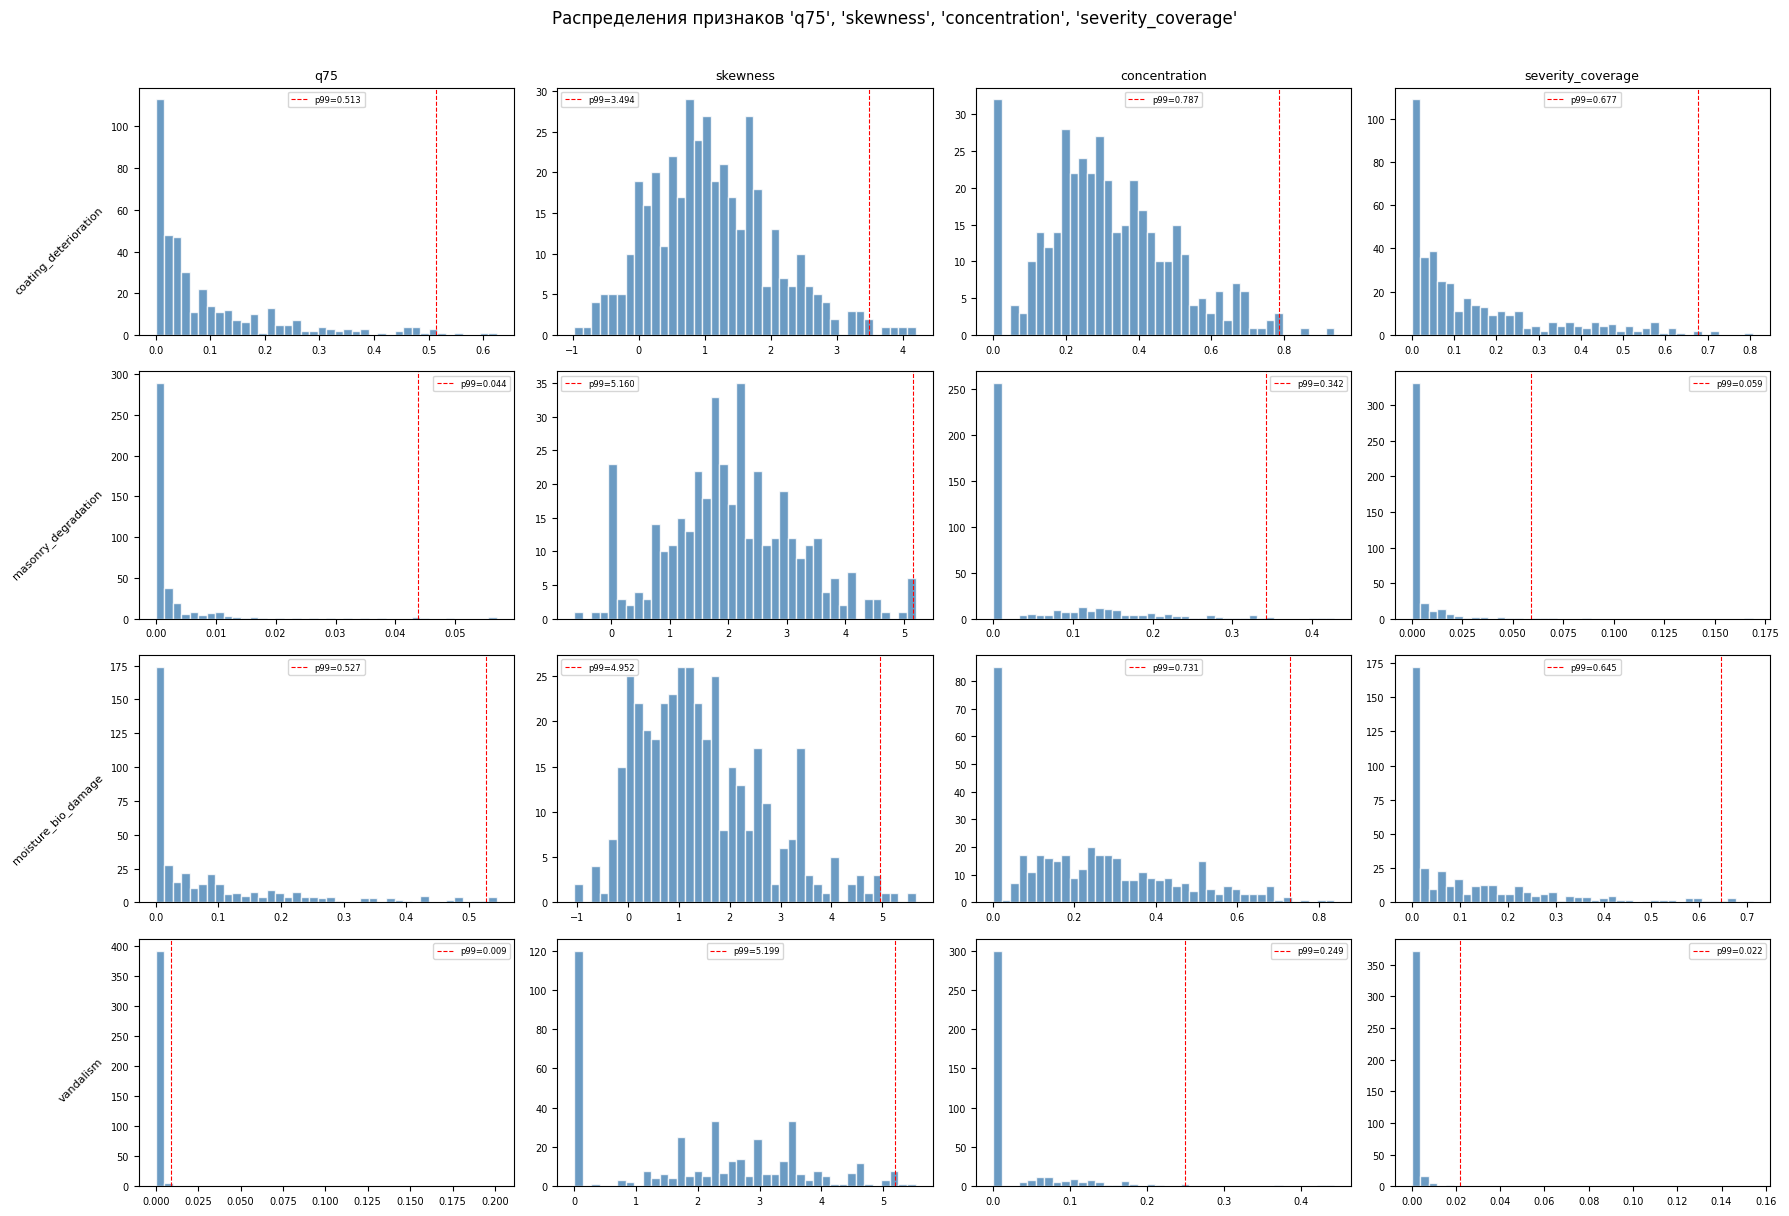

In [ ]:
fig, axes = plt.subplots(len(classes), len(features) // 2,
                          figsize=(18, len(classes) * 3))

for i, cls in enumerate(classes):
    for j, feat in enumerate(features[4:]):
        col = f"{cls}_{feat}"
        vals = df[col].dropna()
        ax = axes[i, j]

        ax.hist(vals, bins=40, edgecolor="white", color="steelblue", alpha=0.8)
        p99 = np.percentile(vals, 99)
        ax.axvline(p99, color="red", linestyle="--", linewidth=0.8,
                   label=f"p99={p99:.3f}")

        if j == 0:
            ax.set_ylabel(cls, fontsize=8, rotation=45, ha="right")
        if i == 0:
            ax.set_title(feat, fontsize=9)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6)

fig.suptitle("Распределения признаков 'q75', 'skewness', 'concentration', 'severity_coverage'", y=1.01)
plt.tight_layout()
plt.savefig("plot_feature_distributions.png", dpi=130, bbox_inches="tight")
plt.show()

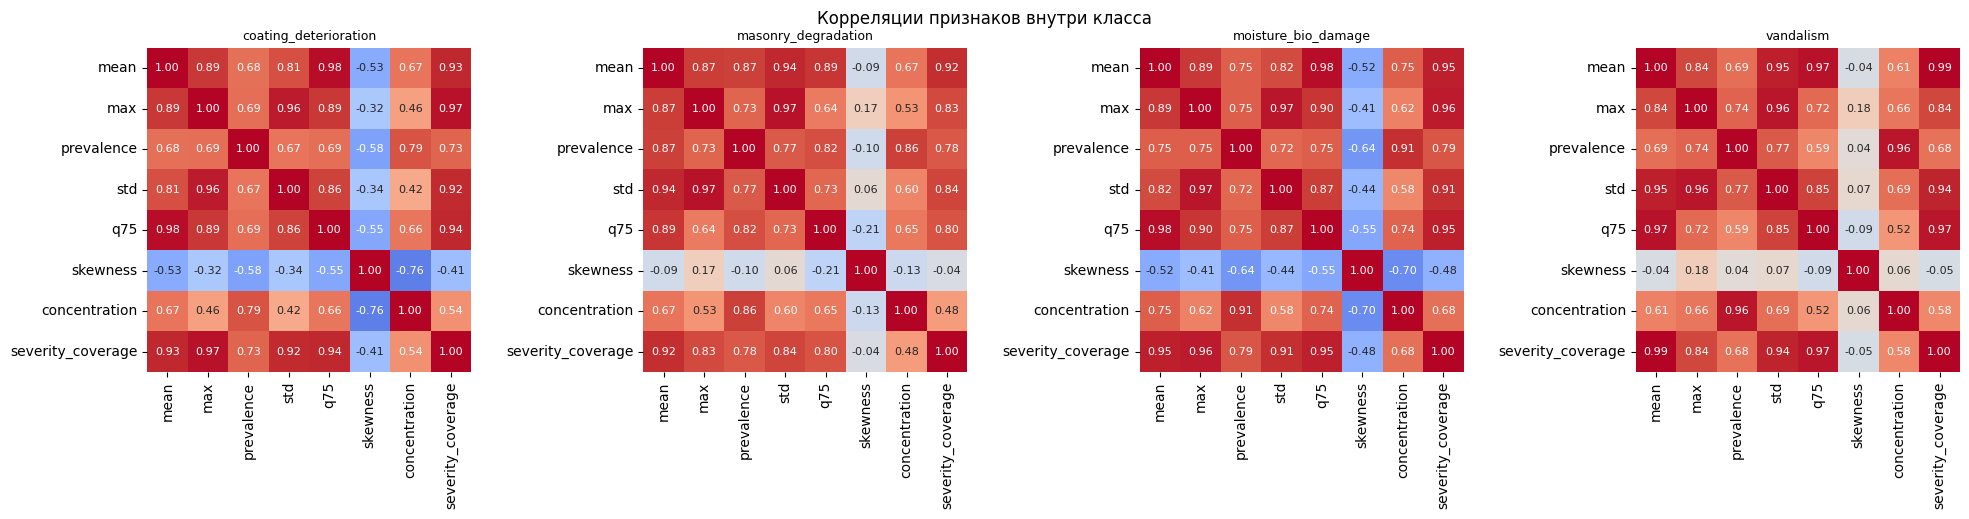

In [ ]:
# Корреляция признаков внутри каждого класса
fig, axes = plt.subplots(1, len(classes), figsize=(20, 5))

for ax, cls in zip(axes, classes):
    cols = [f"{cls}_{f}" for f in features]
    corr = df[cols].corr()
    corr.index = corr.columns = features
    sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, square=True, cbar=False, annot_kws={"size": 8})
    ax.set_title(cls, fontsize=9)

fig.suptitle("Корреляции признаков внутри класса")
plt.tight_layout()
plt.savefig("plot_feature_corr.png", dpi=130)
plt.show()


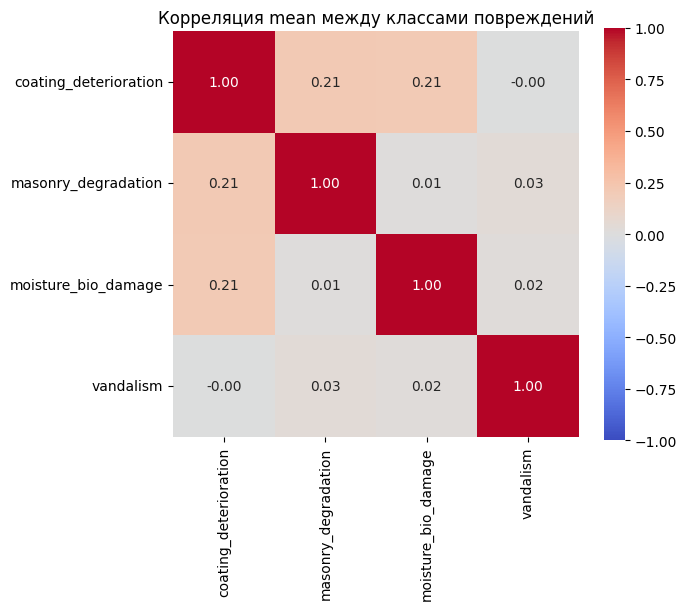

In [ ]:
#  Корреляция mean между классами
mean_cols = {cls: f"{cls}_mean" for cls in classes}
df_means = df[[v for v in mean_cols.values()]].copy()
df_means.columns = classes

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df_means.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Корреляция mean между классами повреждений")
plt.tight_layout()
plt.savefig("plot_class_corr.png", dpi=130)
plt.show()


In [ ]:
# Топ-5 лучших и худших даний по каждому классу на основании признака mean 
for cls in classes:
    col = f"{cls}_mean"
    top5  = df.nlargest(5, col)[["building_name", col]]
    bot5  = df.nsmallest(5, col)[["building_name", col]]  
    print(f"  {cls}")   
    print(f"  Top-5:\n{top5.to_string(index=False)}")
    print(f"  Bottom-5:\n{bot5.to_string(index=False)}")


  coating_deterioration
  Top-5:
 building_name  coating_deterioration_mean
            18                    0.500476
            35                    0.470544
           168                    0.443050
           158                    0.426201
           284                    0.414890
  Bottom-5:
 building_name  coating_deterioration_mean
           400                    0.000081
           302                    0.000088
           266                    0.000117
           152                    0.000122
            72                    0.000158
  masonry_degradation
  Top-5:
 building_name  masonry_degradation_mean
            36                  0.049613
           200                  0.036614
           113                  0.034202
            35                  0.031974
            54                  0.031341
  Bottom-5:
 building_name  masonry_degradation_mean
            45                       0.0
           286                       0.0
           289             

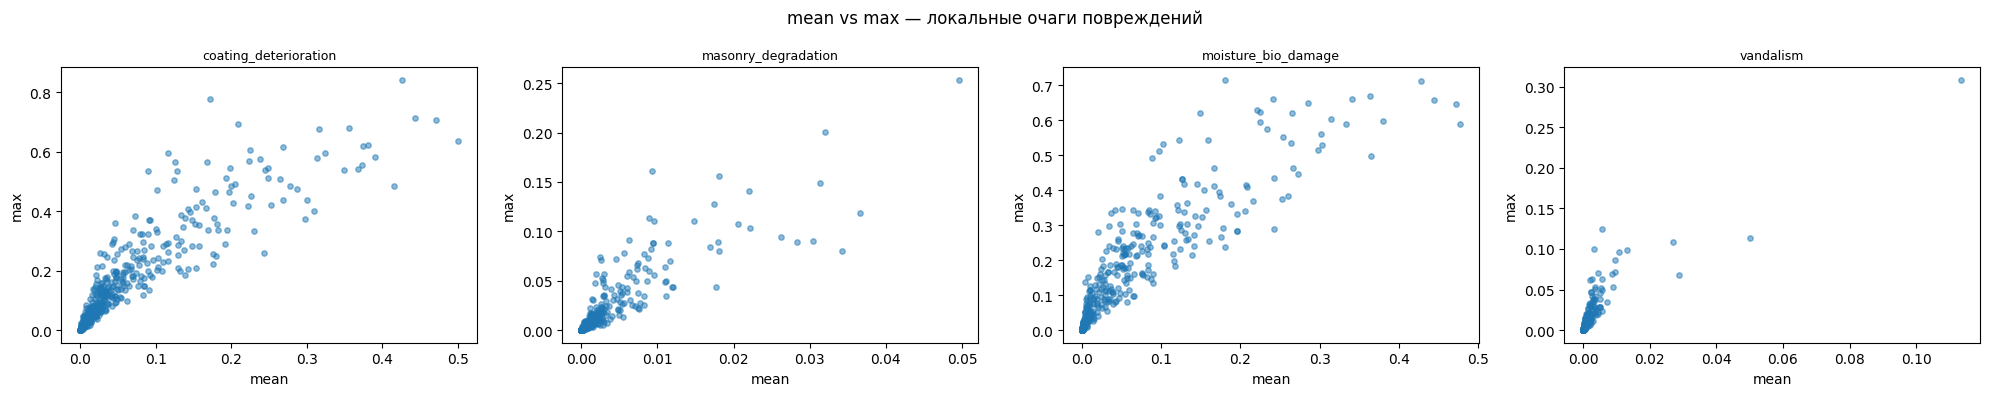

In [ ]:
# Scatterplo 
fig, axes = plt.subplots(1, len(classes), figsize=(20, 4))

for ax, cls in zip(axes, classes):
    x = df[f"{cls}_mean"]
    y = df[f"{cls}_max"]
    ax.scatter(x, y, alpha=0.5, s=15)

    # Здания с аномально высоким max при низком mean
    outliers = df[(y > y.quantile(0.95)) & (x < x.quantile(0.5))]
    for _, row in outliers.iterrows():
        ax.annotate(str(row["building_name"])[:12],
                    (row[f"{cls}_mean"], row[f"{cls}_max"]),
                    fontsize=5, alpha=0.7)

    ax.set_xlabel("mean"); ax.set_ylabel("max")
    ax.set_title(cls, fontsize=9)

fig.suptitle("mean vs max — локальные очаги повреждений")
plt.tight_layout()
plt.savefig("plot_mean_vs_max.png", dpi=130)
plt.show()


## GradIO инструмент для разметки (LLM)

Алгоритм для ранжирования изображений фасадов

1. случайным образом выбираем 2 фасада.

2. Подгоняем их под одинаковый размер для удобства просмотра.

3. Кнопки "Левое хуже" (означает 0), "Правое хуже" (означает 1), "Одинаково" (означает 2) и "Пропустить" (если сложно оценить фото).

4. Как только нажимаем кнопку оценки, скрипт дописывает строчку в файл data/processed/ranking_pairs.csv и тут же показывает следующую пару. 

In [ ]:
def norm_name(x):
    s = str(x)
    return s[:-2] if (s.endswith('.0') and s[:-2].lstrip('-').isdigit()) else s

def find_image(name):
    for ext in ['.jpg', '.JPG', '.png']:
        p = os.path.join(images_dir, f"{name}{ext}")
        if os.path.exists(p):
            return p
    return None

def load_image(path):
    return ImageOps.exif_transpose(Image.open(path))

df_global = pd.read_csv(features_csv)
df_global['building_name'] = df_global['building_name'].apply(norm_name)

def setup_session(session_class):
    threshold = annotation_threshold[session_class]
    df_active = df_global[df_global[f"{session_class}_max"] > threshold].copy()

    valid_buildings, valid_paths = [], {}
    for b in df_active['building_name'].dropna():
        b = norm_name(b)
        p = find_image(b)
        if p:
            valid_buildings.append(b)
            valid_paths[b] = p

    df_sorted = (
        df_active[df_active['building_name'].isin(valid_buildings)]
        .sort_values(f"{session_class}_mean")
        .reset_index(drop=True)
    )
    rank_index = {norm_name(row['building_name']): i
                  for i, row in df_sorted.iterrows()}

    output_csv = os.path.join(output_dir, f"ranking_pairs_{session_class}.csv")
    seen_pairs = set()
    if os.path.exists(output_csv):
        for _, row in pd.read_csv(output_csv).iterrows():
            seen_pairs.add(frozenset([norm_name(str(row['image_a'])),
                                      norm_name(str(row['image_b']))]))
    else:
        with open(output_csv, 'w', newline='', encoding='utf-8') as f:
            csv.writer(f).writerow(['image_a', 'image_b', 'winner'])

    return df_sorted, rank_index, valid_paths, seen_pairs, output_csv

def sample_pair(df_sorted, seen_pairs):
    for _ in range(300):
        i = random.randint(0, len(df_sorted) - 2)
        j = random.randint(i + 1, min(i + adapt_window, len(df_sorted) - 1))
        a = norm_name(df_sorted.loc[i, 'building_name'])
        b = norm_name(df_sorted.loc[j, 'building_name'])
        if frozenset([a, b]) not in seen_pairs:
            return a, b
    return None, None

def load_recent(output_csv, n=8):
    if not os.path.exists(output_csv):
        return pd.DataFrame(columns=['image_a', 'image_b', 'winner'])
    return (pd.read_csv(output_csv)
              .tail(n)[['image_a', 'image_b', 'winner']]
              .iloc[::-1]
              .reset_index(drop=True))

with gr.Blocks(title="Ranking Annotator", theme=gr.themes.Soft()) as app:

    state = gr.State({
        "df_sorted": None, "rank_index": None, "valid_paths": None,
        "seen_pairs": set(), "output_csv": None,
        "a": None, "b": None, "session": None,
    })

    gr.Markdown("# 🏠 Разметка пар зданий")

    with gr.Row():
        session_dd = gr.Dropdown(choices=list(annotation_threshold),
                                 value=list(annotation_threshold)[0],
                                 label="Класс повреждений", scale=3)
        start_btn  = gr.Button("▶ Начать / Сменить сессию",
                               variant="primary", scale=1)

    progress_md = gr.Markdown("*Выбери класс и нажми «Начать»*")

    with gr.Row():
        img_left  = gr.Image(label="ЛЕВОЕ",  height=450, show_label=True)
        img_right = gr.Image(label="ПРАВОЕ", height=450, show_label=True)

    with gr.Row():
        btn_left  = gr.Button("⬅ Левое хуже",  variant="primary",   scale=3)
        btn_tie   = gr.Button("= Одинаково",   variant="secondary", scale=1)
        btn_right = gr.Button("Правое хуже ➡", variant="primary",   scale=3)
        btn_skip  = gr.Button("↷ Пропустить",  variant="secondary", scale=1)

    gr.Markdown("### Последние аннотации")
    log_table = gr.Dataframe(interactive=False, wrap=True)

    def _img(path, side):
        return gr.update(value=load_image(path), label=side)

    def _empty(side):
        return gr.update(value=None, label=side)

    def start(session_class, st):
        df_s, rank, paths, seen, out_csv = setup_session(session_class)
        a, b = sample_pair(df_s, seen)
        st = {**st, "df_sorted": df_s, "rank_index": rank, "valid_paths": paths,
              "seen_pairs": seen, "output_csv": out_csv,
              "a": a, "b": b, "session": session_class}
        if a is None:
            return st, _empty("ЛЕВОЕ"), _empty("ПРАВОЕ"), "Нет новых пар", load_recent(out_csv)
        prog = (f"**{session_class.upper()}** | "
                f"Размечено: {len(seen)} / ~{target_pairs} | "
                f"Зданий в пуле: {len(df_s)} | "
                f"Ранги: {rank[a]+1} vs {rank[b]+1}")
        return st, _img(paths[a], f"ЛЕВОЕ: {a}"), _img(paths[b], f"ПРАВОЕ: {b}"), prog, load_recent(out_csv)

    def vote(winner_code, st):
        a, b = st["a"], st["b"]
        if a is None:
            return st, _empty("ЛЕВОЕ"), _empty("ПРАВОЕ"), "Сначала запусти сессию", pd.DataFrame()

        st["seen_pairs"].add(frozenset([a, b]))
        with open(st["output_csv"], 'a', newline='', encoding='utf-8') as f:
            csv.writer(f).writerow([a, b, winner_code])

        new_a, new_b = sample_pair(st["df_sorted"], st["seen_pairs"])
        st = {**st, "a": new_a, "b": new_b}

        if new_a is None:
            return st, _empty("ЛЕВОЕ"), _empty("ПРАВОЕ"), "✅ Все пары в окне размечены!", load_recent(st["output_csv"])

        n    = len(st["seen_pairs"])
        rank = st["rank_index"]
        prog = (f"**{st['session'].upper()}** | "
                f"Размечено: {n} / ~{target_pairs} | "
                f"Ранги: {rank[new_a]+1} vs {rank[new_b]+1}"
                )
        paths = st["valid_paths"]
        return st, _img(paths[new_a], f"ЛЕВОЕ: {new_a}"), _img(paths[new_b], f"ПРАВОЕ: {new_b}"), prog, load_recent(st["output_csv"])

    def skip(st):
        if st["df_sorted"] is None:
            return st, _empty("ЛЕВОЕ"), _empty("ПРАВОЕ"), "Сначала запусти сессию", pd.DataFrame()
        new_a, new_b = sample_pair(st["df_sorted"], st["seen_pairs"])
        st = {**st, "a": new_a, "b": new_b}
        if new_a is None:
            return st, _empty("ЛЕВОЕ"), _empty("ПРАВОЕ"), "Все пары размечены", load_recent(st["output_csv"])
        rank  = st["rank_index"]
        paths = st["valid_paths"]
        n     = len(st["seen_pairs"])
        prog  = (f"**{st['session'].upper()}** | "
                 f"Размечено: {n} / ~{target_pairs} | "
                 f"Ранги: {rank[new_a]+1} vs {rank[new_b]+1}")
        return st, _img(paths[new_a], f"ЛЕВОЕ: {new_a}"), _img(paths[new_b], f"ПРАВОЕ: {new_b}"), prog, load_recent(st["output_csv"])

    outs = [state, img_left, img_right, progress_md, log_table]
    start_btn.click(start, [session_dd, state], outs)
    btn_left .click(lambda s: vote("0", s), state, outs)
    btn_right.click(lambda s: vote("1", s), state, outs)
    btn_tie  .click(lambda s: vote("2", s), state, outs)
    btn_skip .click(skip, state, outs)

app.launch()


/tmp/ipykernel_16121/4285229677.py:68: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Ranking Annotator", theme=gr.themes.Soft()) as app:


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
